# Simplex-Tree Experiments on the Spambase (binary, MLP) Dataset

**Setup.** UCI Spambase (binary, 4601 rows, 57 features): word / character frequency features distinguishing spam from ham email. Scale to [0,1], target +1 / -1, RFE keeps the top 4 features. The explained network is a **fast feed-forward MLP**. Build a simplex-tree surrogate and find the **non-convex** parts of its decision boundary.

**Experiment 1.** Remove the non-convex simplices -> the surrogate's **generalisation coefficient goes up**.

**Experiment 2.** Follow LIME's vector at a non-convex point (the MLP leaves the target class) and contrast with a convex point.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import sys, os, warnings, time
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC

# Make the SimplexTreeClassifier package importable.
here = os.getcwd()
for p in (os.path.join(here, '..', '..'), os.path.join(here, '..')):
    p = os.path.abspath(p)
    if p not in sys.path:
        sys.path.insert(0, p)
if here not in sys.path:
    sys.path.insert(0, here)

from in2D.classifying.classes.simplex_tree_classifier import SimplexTreeClassifier
from in2D.tests.data_generators.generate_data_nd import create_simplex_vertices
from paper_experiments_utils import (
    FeatureGRU, FeatureMLP, train_nn, predict_classes, predict_proba,
    find_nonconvex_leaves, build_convex_surrogate,
    leaf_key_for_point, gen_coef,
    make_lime_explainer, lime_direction, push_along_lime)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cpu


### 1. Load & preprocess (RFE pipeline)

In [2]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

ds = fetch_openml(name='spambase', version=1, as_frame=True, parser='auto')
X_df = ds.data.select_dtypes(include=[np.number]).astype(np.float64)
all_feature_names = [f'f{i+1}' for i in range(X_df.shape[1])]
classes = np.unique(ds.target.astype(str))
# binary target +1 / -1
y = np.where(ds.target.astype(str).values == classes[0], -1.0, 1.0)
print('spambase shape:', X_df.shape, '  class counts:',
      dict(zip(*np.unique(y, return_counts=True))))

X_all = MinMaxScaler().fit_transform(X_df.values)

X_tr_all, X_te_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y)

N_SELECT = 4
rfe = RFE(LogisticRegression(max_iter=2000),
          n_features_to_select=min(N_SELECT, X_all.shape[1]))
rfe.fit(X_tr_all, y_train)
sel = rfe.support_
feature_names = [n for n, k in zip(all_feature_names, sel) if k]
X_train = X_tr_all[:, sel]
X_test  = X_te_all[:, sel]
n_features = int(sel.sum())

print(f'RFE-selected features ({n_features}): {feature_names}')
print(f'{X_all.shape[0]} samples | Train {len(X_train)} | Test {len(X_test)}')
print(f'Class balance (train): +1={int((y_train==1).sum())}  -1={int((y_train==-1).sum())}')


spambase shape: (4601, 57)   class counts: {np.float64(-1.0): np.int64(2788), np.float64(1.0): np.int64(1813)}


RFE-selected features (4): ['f7', 'f23', 'f25', 'f53']
4601 samples | Train 3680 | Test 921
Class balance (train): +1=1450  -1=2230


### 2. Train the MLP

Selected features -> feed-forward MLP (2 hidden layers of 64, ReLU) -> sigmoid (binary) or softmax (multiclass). This replaces the recurrent GRU with a plain MLP so training and surrogate evaluation run faster.

In [3]:
EPOCHS, BATCH_SIZE, LR = 200, 32, 0.01
n_classes = len(np.unique(y_train))
torch.manual_seed(42); np.random.seed(42)

nn_model = FeatureMLP(n_features, n_classes=n_classes, hidden=64).to(device)
NN_PATH = os.path.join(os.getcwd(), 'models', 'spambase_mlp.pt')
if os.path.exists(NN_PATH):
    nn_model.load_state_dict(torch.load(NN_PATH, map_location=device)); nn_model.eval()
    print(f'Loaded nn_model <- {NN_PATH}')
else:
    t0 = time.time()
    train_nn(nn_model, X_train, y_train, X_test, y_test,
             epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE, device=device)
    print(f'NN trained in {time.time()-t0:.1f}s')
    os.makedirs(os.path.dirname(NN_PATH), exist_ok=True)
    torch.save(nn_model.state_dict(), NN_PATH); print(f'Saved nn_model -> {NN_PATH}')

nn_pred = lambda Z: predict_classes(nn_model, Z, device=device)
print(f'NN train acc: {accuracy_score(y_train, nn_pred(X_train)):.4f}')
print(f'NN test  acc: {accuracy_score(y_test,  nn_pred(X_test)):.4f}')


Loaded nn_model <- /home/yasmin/SimplexTreeClassifier/in2D/to_save_for_paper/models/spambase_mlp.pt
NN train acc: 0.8856
NN test  acc: 0.8578


### Learning curve

Training loss as a function of the number of epochs (0-300). The model used by the rest of the notebook is the 200-epoch one above.

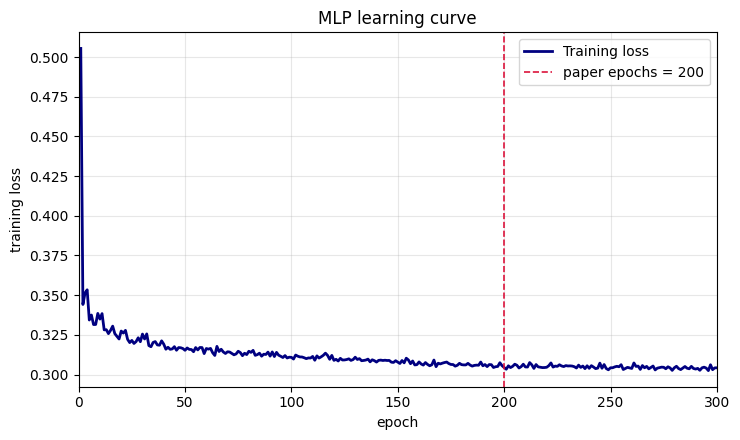

In [4]:
# Train a fresh network for 300 epochs only to plot the loss curve 0-300.
torch.manual_seed(42); np.random.seed(42)
curve_model = FeatureMLP(n_features, n_classes=n_classes, hidden=64).to(device)
train_nn(curve_model, X_train, y_train, X_test, y_test,
         epochs=300, lr=0.01, batch_size=32, device=device)

epochs_axis = range(1, len(curve_model.loss_history) + 1)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(epochs_axis, curve_model.loss_history, color='navy', lw=2,
        label='Training loss')
ax.axvline(200, color='crimson', ls='--', lw=1.2,
           label=f'paper epochs = 200')
ax.set_xlim(0, 300); ax.set_xlabel('epoch'); ax.set_ylabel('training loss')
ax.set_title('MLP learning curve')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


### 3. Build the simplex-tree surrogate

Fill `[0,1]^d` with random points labelled by the GRU, then add the real train points so every class is represented. The simplex tree (LinearSVC head, OvR-multiclass when n_classes>2) is trained on this fill set.

In [5]:
# Fill [0,1]^d with random points labelled by the GRU, then add the real train
# set so every class is represented. The surrogate fits this fill distribution.
N_FILL, C_PARAM = 5000, 10000
np.random.seed(42)
X_fill = np.random.uniform(0, 1, (N_FILL, n_features))
y_fill = nn_pred(X_fill)
X_fill = np.vstack([X_fill, X_train])
y_fill = np.concatenate([y_fill, nn_pred(X_train)])
print(f'Surrogate training points: {len(X_fill)}   '
      f'class counts: {dict(zip(*np.unique(y_fill, return_counts=True)))}')


Surrogate training points: 8680   class counts: {np.float64(-1.0): np.int64(3698), np.float64(1.0): np.int64(4982)}


### Accuracy vs subdivision levels

Sweep the surrogate's `subdivision_levels` and plot the test agreement with the NN and the test accuracy against true labels.

subdivision_levels=1: leaves=     5  agreement-with-NN=0.8132  acc-vs-labels=0.7253


subdivision_levels=2: leaves=    25  agreement-with-NN=0.8295  acc-vs-labels=0.7438


subdivision_levels=3: leaves=   125  agreement-with-NN=0.8827  acc-vs-labels=0.7861


subdivision_levels=4: leaves=   625  agreement-with-NN=0.9544  acc-vs-labels=0.8230


subdivision_levels=5: leaves=  3125  agreement-with-NN=0.9815  acc-vs-labels=0.8480


subdivision_levels=6: leaves= 15625  agreement-with-NN=0.9913  acc-vs-labels=0.8512

Highest agreement with NN at subdivision level 6 (= 0.9913)


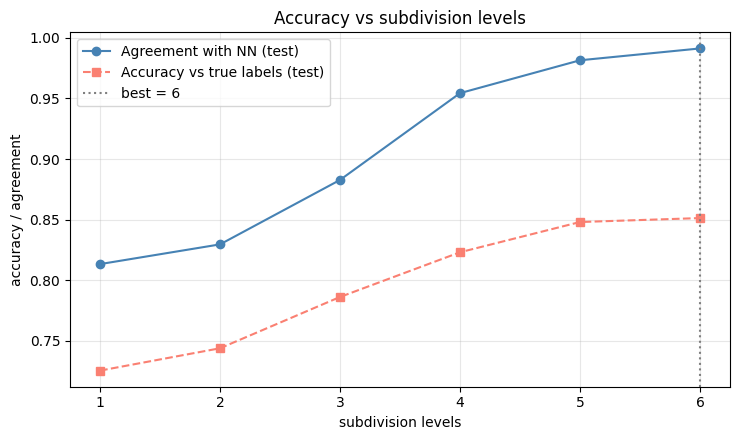

In [6]:
# Sweep subdivision_levels and report (a) surrogate-NN agreement on the test
# set, (b) surrogate accuracy on the true labels.
sub_levels = [1, 2, 3, 4, 5, 6]
agree_with_nn, acc_vs_labels = [], []
y_nn_te = nn_pred(X_test)
for L in sub_levels:
    m = SimplexTreeClassifier(
        vertices=create_simplex_vertices(n_features),
        classifier=LinearSVC(C=C_PARAM, max_iter=20000),
        subdivision_levels=L)
    m.fit(X_fill, y_fill)
    agree_with_nn.append(accuracy_score(y_nn_te, m.predict(X_test)))
    acc_vs_labels.append(accuracy_score(y_test, m.predict(X_test)))
    print(f'subdivision_levels={L}: leaves={len(m.leaf_simplexes):6d}  '
          f'agreement-with-NN={agree_with_nn[-1]:.4f}  '
          f'acc-vs-labels={acc_vs_labels[-1]:.4f}')

best_i = int(np.argmax(agree_with_nn))
print(f'\nHighest agreement with NN at subdivision level {sub_levels[best_i]} '
      f'(= {agree_with_nn[best_i]:.4f})')

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(sub_levels, agree_with_nn, 'o-', color='steelblue',
        label='Agreement with NN (test)')
ax.plot(sub_levels, acc_vs_labels, 's--', color='salmon',
        label='Accuracy vs true labels (test)')
ax.axvline(sub_levels[best_i], color='gray', ls=':',
           label=f'best = {sub_levels[best_i]}')
ax.set_xlabel('subdivision levels')
ax.set_ylabel('accuracy / agreement')
ax.set_title('Accuracy vs subdivision levels')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


### Initial surrogate at subdivision_levels = 4

Subdivision levels chosen to give a deep enough tree that the surrogate starts to **overfit the fill points** -- exactly the regime where pruning the non-convex leaves should help.

In [7]:
import pickle
SUBDIVISION_LEVELS = 4
STC_PATH = os.path.join(os.getcwd(), 'models', 'spambase_stc.pkl')
if os.path.exists(STC_PATH):
    with open(STC_PATH, 'rb') as f:
        stc = pickle.load(f)
    print(f'Loaded stc <- {STC_PATH}')
else:
    stc = SimplexTreeClassifier(
        vertices=create_simplex_vertices(n_features),
        classifier=LinearSVC(C=C_PARAM, max_iter=20000),
        subdivision_levels=SUBDIVISION_LEVELS)
    stc.fit(X_fill, y_fill)
    os.makedirs(os.path.dirname(STC_PATH), exist_ok=True)
    with open(STC_PATH, 'wb') as f:
        pickle.dump(stc, f)
    print(f'Saved stc -> {STC_PATH}')
print(f'Surrogate leaves: {len(stc.leaf_simplexes)}')
print(f'Agreement (fill) = {accuracy_score(y_fill, stc.predict(X_fill)):.4f}')
print(f'Agreement (test) = {accuracy_score(nn_pred(X_test), stc.predict(X_test)):.4f}')


Loaded stc <- /home/yasmin/SimplexTreeClassifier/in2D/to_save_for_paper/models/spambase_stc.pkl
Surrogate leaves: 625


Agreement (fill) = 0.9286


Agreement (test) = 0.9544


### 4. Find non-convex regions

A leaf is **non-convex** if the boundary bends the wrong way versus any neighbour for ANY of the OvR hyperplanes. `epsilon` controls strictness (smaller = only severe curvature).

In [8]:
EPSILON = 0.05
crossing = stc.identify_crossing_simplices()
depths = find_nonconvex_leaves(stc, epsilon=EPSILON)
print(f'Boundary-crossing simplices : {len(crossing)}')
print(f'Non-convex simplices        : {len(depths)}  '
      f'({len(depths) / max(len(stc.leaf_simplexes),1):.0%} of leaves, '
      f'epsilon={EPSILON})')

nonconvex_keys = set(depths.keys())
test_in_nc = np.array([leaf_key_for_point(stc, x) in nonconvex_keys for x in X_test])
print(f'Test points inside a non-convex region: {test_in_nc.sum()} / {len(X_test)}')


Boundary-crossing simplices : 472
Non-convex simplices        : 439  (70% of leaves, epsilon=0.05)


Test points inside a non-convex region: 754 / 921


## Experiment 1 -- Non-convex removal reduces overfitting

The surrogate copies the GRU from the fill points; with too many leaves it **overfits**. We remove the non-convex simplices (deepest bend first, up to 25% of leaves) and measure the **generalisation coefficient**

$$\text{gen\_coef} = \frac{\text{test accuracy}}{\text{train accuracy}}\quad(\text{higher = less overfitting}).$$

In [9]:
# Remove non-convex leaves -- deepest bend first, up to 25% of the initial
# leaf count (total budget). Refits after each pass.
def make_model():
    return SimplexTreeClassifier(
        vertices=create_simplex_vertices(n_features),
        classifier=LinearSVC(C=C_PARAM, max_iter=20000),
        subdivision_levels=SUBDIVISION_LEVELS)

STC_CONVEX_PATH = os.path.join(os.getcwd(), 'models', 'spambase_stc_convex.pkl')
if os.path.exists(STC_CONVEX_PATH):
    with open(STC_CONVEX_PATH, 'rb') as f:
        stc_convex = pickle.load(f)
    print(f'Loaded stc_convex <- {STC_CONVEX_PATH}')
else:
    stc_convex = build_convex_surrogate(make_model, X_fill, y_fill,
                                        epsilon=EPSILON,
                                        max_remove_frac=0.25, max_iter=8)
    os.makedirs(os.path.dirname(STC_CONVEX_PATH), exist_ok=True)
    with open(STC_CONVEX_PATH, 'wb') as f:
        pickle.dump(stc_convex, f)
    print(f'Saved stc_convex -> {STC_CONVEX_PATH}')


Loaded stc_convex <- /home/yasmin/SimplexTreeClassifier/in2D/to_save_for_paper/models/spambase_stc_convex.pkl


In [10]:
y_nn_test = nn_pred(X_test)

def surrogate_scores(tree):
    train_agree = accuracy_score(y_fill,    tree.predict(X_fill))
    test_agree  = accuracy_score(y_nn_test, tree.predict(X_test))
    true_acc    = accuracy_score(y_test,    tree.predict(X_test))
    return train_agree, test_agree, train_agree - test_agree, test_agree / max(train_agree,1e-9), true_acc

b_tr, b_te, b_gap, b_gc, b_acc = surrogate_scores(stc)
c_tr, c_te, c_gap, c_gc, c_acc = surrogate_scores(stc_convex)

print(f'{"":28s} {"Original":>12s} {"Non-convex removed":>20s}')
print('-' * 64)
print(f'{"Leaves":28s} {len(stc.leaf_simplexes):>12d} {len(stc_convex.leaf_simplexes):>20d}')
print(f'{"Train agreement (vs NN)":28s} {b_tr:>12.4f} {c_tr:>20.4f}')
print(f'{"Test  agreement (vs NN)":28s} {b_te:>12.4f} {c_te:>20.4f}')
print(f'{"Gap (train - test)":28s} {b_gap:>12.4f} {c_gap:>20.4f}')
print(f'{"Generalisation coef.":28s} {b_gc:>12.4f} {c_gc:>20.4f}')
print(f'{"Test accuracy (vs labels)":28s} {b_acc:>12.4f} {c_acc:>20.4f}')
print()
print(f'Generalisation coefficient: {b_gc:.4f} -> {c_gc:.4f}  '
      f'({c_gc - b_gc:+.4f}, {"IMPROVED" if c_gc > b_gc else "did not improve"})')
print(f'Test accuracy vs labels  : {b_acc:.4f} -> {c_acc:.4f}  '
      f'({c_acc - b_acc:+.4f})')


                                 Original   Non-convex removed
----------------------------------------------------------------
Leaves                                625                  469
Train agreement (vs NN)            0.9286               0.9078
Test  agreement (vs NN)            0.9544               0.9121
Gap (train - test)                -0.0258              -0.0042
Generalisation coef.               1.0278               1.0046
Test accuracy (vs labels)          0.8230               0.8002

Generalisation coefficient: 1.0278 -> 1.0046  (-0.0232, did not improve)
Test accuracy vs labels  : 0.8230 -> 0.8002  (-0.0228)


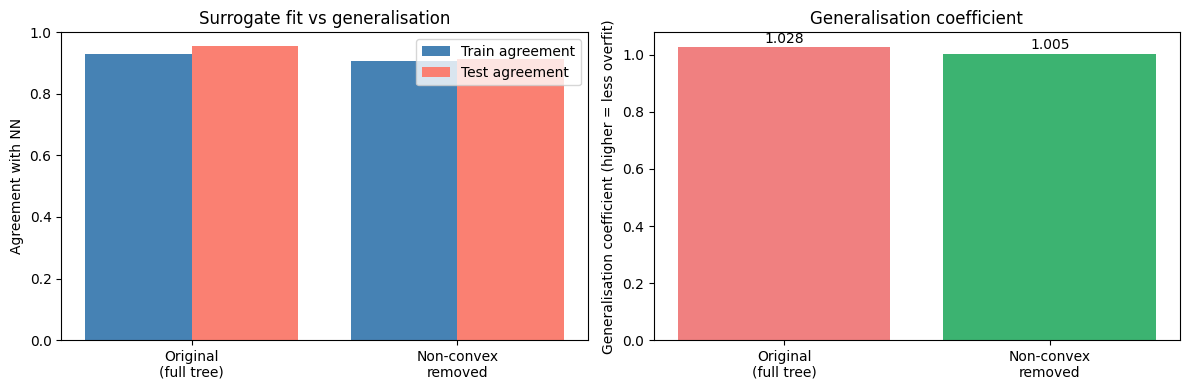

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Original\n(full tree)', 'Non-convex\nremoved']
x = np.arange(2)

axes[0].bar(x - 0.2, [b_tr, c_tr], 0.4, label='Train agreement', color='steelblue')
axes[0].bar(x + 0.2, [b_te, c_te], 0.4, label='Test agreement',  color='salmon')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 1); axes[0].set_ylabel('Agreement with NN')
axes[0].set_title('Surrogate fit vs generalisation'); axes[0].legend()

axes[1].bar(x, [b_gc, c_gc], color=['lightcoral', 'mediumseagreen'])
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Generalisation coefficient (higher = less overfit)')
axes[1].set_title('Generalisation coefficient')
for i, v in enumerate([b_gc, c_gc]):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()


### Headline: the pruned surrogate vs the GRU

Same metric (true-label test / train) for both. If removal really cuts overfitting, the pruned surrogate's gen-coef should pass the GRU's.

Model                                 Train     Test   Gen-coef
----------------------------------------------------------------
MLP (network being explained)        0.8856   0.8578     0.9686
Simplex-tree surrogate               0.7755   0.8002     1.0318
----------------------------------------------------------------
Surrogate gen-coef 1.0318  vs  MLP gen-coef 0.9686  -> HIGHER (the surrogate overfits less than the MLP)
Note: a higher gen-coef means LESS OVERFITTING, not higher absolute accuracy.


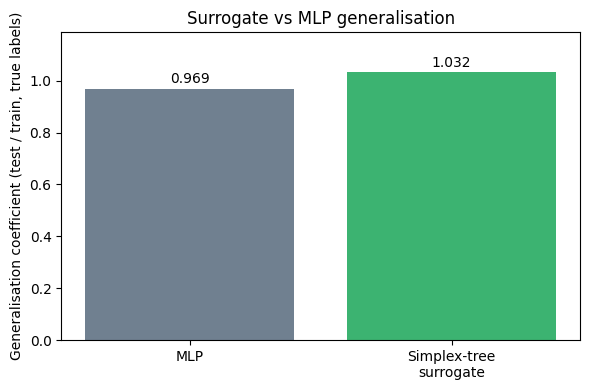

In [12]:
# Same metric (true-label test / train) for both. If pruning really cuts
# overfitting, the pruned surrogate's gen-coef should pass the MLP's.
nn_tr, nn_te, nn_gc = gen_coef(nn_pred, X_train, y_train, X_test, y_test)
p_tr,  p_te,  p_gc  = gen_coef(stc_convex.predict, X_train, y_train, X_test, y_test)

print(f'{"Model":34s} {"Train":>8s} {"Test":>8s} {"Gen-coef":>10s}')
print('-' * 64)
print(f'{"MLP (network being explained)":34s} {nn_tr:>8.4f} {nn_te:>8.4f} {nn_gc:>10.4f}')
print(f'{"Simplex-tree surrogate":34s} {p_tr:>8.4f} {p_te:>8.4f} {p_gc:>10.4f}')
print('-' * 64)
print(f'Surrogate gen-coef {p_gc:.4f}  vs  MLP gen-coef {nn_gc:.4f}  -> '
      f'{"HIGHER (the surrogate overfits less than the MLP)" if p_gc > nn_gc else "lower (NN already generalises well)"}')
print('Note: a higher gen-coef means LESS OVERFITTING, not higher absolute accuracy.')

fig, ax = plt.subplots(figsize=(6, 4))
names = ['MLP', 'Simplex-tree\nsurrogate']
vals  = [nn_gc, p_gc]
bars = ax.bar(names, vals, color=['slategray', 'mediumseagreen'])
ax.set_ylabel('Generalisation coefficient (test / train, true labels)')
ax.set_title(f'Surrogate vs MLP generalisation')
ax.set_ylim(0, max(vals) * 1.15)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()


## Experiment 2 -- LIME's explanation vector points *out* of the target class in a non-convex region

The NN assigns $x_0$ a class -- call it the **target** class (the class LIME is explaining). LIME fits a local linear model and its weight vector points (according to LIME) toward **increasing target membership**. We follow that direction from $x_0$ and watch the NN's real probability of the target class.

1. pick a point $x_0$ inside a non-convex region (found via the simplex tree);
2. extract LIME's vector $w$ at $x_0$;
3. read off the most influential features (largest $|w|$);
4. follow $d$ -- the direction LIME claims is *deeper into the target class*;
5. show that, because the region is **non-convex**, $P_\text{NN}(\text{target})$ drops below $0.5$. As a control, at a **convex** point the same vector does stay inside the target class, so the failure is caused by non-convexity.

In [13]:
# LIME on the NN. Binary case: NN P(+1) is column 1 of predict_proba.
try:
    import lime, lime.lime_tabular
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lime'])
    import lime, lime.lime_tabular

def nn_proba(X_):
    return predict_proba(nn_model, X_, device=device)

explainer = make_lime_explainer(X_train, feature_names, n_classes=2)
ALPHA = np.linspace(0, 0.4, 81)

def push(point):
    """Step along the direction LIME says reinforces the NN's TARGET class
    (the class the NN itself predicted at `point`). Binary: target in {+1,-1}.
    Returns alphas, NN P(target), LIME P(target), target, w (toward +1), unit d."""
    point = np.asarray(point, dtype=np.float32)
    target = +1 if nn_proba(point)[0, 1] >= 0.5 else -1
    # LIME's label index for class +1 is 1. We always extract weights for
    # class +1 and then orient the step direction by `target`.
    alphas, nn_p_pos, lime_p_pos, w_pos, _ = push_along_lime(
        point, explainer, nn_proba, target_label=1,
        num_features=n_features, alphas=ALPHA)
    # We want d to point toward the target class; reuse push_along_lime's
    # vector via sign flip when target==-1.
    if target == -1:
        # re-run with the negative direction by flipping sign of the step
        alphas = ALPHA
        coef, _, lime_p_fn, grad = lime_direction(
            explainer, nn_proba, point, target_label=1, num_features=n_features)
        d = -grad / max(np.linalg.norm(grad), 1e-12)
        xs = np.clip(point + np.outer(alphas, d), 0, 1)
        nn_p_pos  = nn_proba(xs)[:, 1]
        lime_p_pos = np.clip(lime_p_fn(xs), 0, 1)
        nn_p_target  = 1 - nn_p_pos
        lime_p_target = 1 - lime_p_pos
        return alphas, nn_p_target, lime_p_target, target, coef, d
    d_pos = w_pos / np.linalg.norm(w_pos) if np.linalg.norm(w_pos) > 0 else w_pos
    return alphas, nn_p_pos, lime_p_pos, target, w_pos, d_pos


In [14]:
# Stratify test points by the *depth* of bend in their containing leaf,
# not by binary leaf-membership (which can be all-1 at this epsilon).
# depth=0 means leaf is fully convex; higher depth means stronger bend.
test_depths = np.array([
    depths.get(leaf_key_for_point(stc, x), 0.0) for x in X_test])
print(f'test-point depth: min={test_depths.min():.4f}  '
      f'median={np.median(test_depths):.4f}  max={test_depths.max():.4f}')
print(f'  depth==0 (truly convex leaf): {int((test_depths == 0).sum())}')
if (test_depths > 0).any():
    nz_med = float(np.median(test_depths[test_depths > 0]))
    nc_pool   = np.where(test_depths >= nz_med)[0]   # strongly bent
    conv_pool = np.where(test_depths <  nz_med)[0]   # weak / no bend
else:
    nc_pool   = np.array([], dtype=int)
    conv_pool = np.arange(len(X_test))
print(f'non-convex pool (depth>=median nonzero): {len(nc_pool)}  '
      f'| convex pool (depth<median): {len(conv_pool)}')

# For every CANDIDATE point: run LIME once, record (NN exits target?, drop, lift).
rng = np.random.default_rng(0)
BUDGET = 80                       # LIME calls are slow; sample up to this many

def evaluate(idx_pool, budget):
    cand = idx_pool if len(idx_pool) <= budget else rng.choice(idx_pool, budget, replace=False)
    rows = []
    for i in cand:
        try:
            _, f_t, g_t, _, _, _ = push(X_test[int(i)])
        except Exception:
            continue
        rows.append((int(i), float(f_t[0]), float(f_t.min()), float(f_t[-1]),
                     float(g_t[0]), float(g_t[-1])))
    return rows

print('Running LIME on non-convex pool...');  nc_rows   = evaluate(nc_pool,   BUDGET)
print('Running LIME on convex pool...');     conv_rows = evaluate(conv_pool, BUDGET)
print(f'  nc evaluated: {len(nc_rows)}   conv evaluated: {len(conv_rows)}')

# Non-convex pick: LIME P(target) rises while NN P(target) drops below 0.5.
# If no point actually exits the target class, fall back to "biggest NN drop".
nc_exits = [(i, f0, fmin, fend, g0, gend) for (i, f0, fmin, fend, g0, gend) in nc_rows
            if gend > g0 and fmin < 0.5]
if nc_exits:
    nc_idx, nc_kind = max(nc_exits, key=lambda r: (r[1] - 0.5) + (0.5 - r[2]))[0], 'strong'
elif nc_rows:
    nc_idx, nc_kind = max(nc_rows, key=lambda r: r[1] - r[2])[0], 'weak'
    print('NOTE: no non-convex point fully flips NN; using biggest-drop fallback.')
else:
    nc_idx, nc_kind = None, 'none'

# Convex pick: NN STAYS in target along LIME's direction. Prefer biggest lift.
conv_stays = [(i, f0, fmin, fend, g0, gend) for (i, f0, fmin, fend, g0, gend) in conv_rows
              if gend > g0 and fmin >= 0.5]
if conv_stays:
    conv_idx = max(conv_stays, key=lambda r: r[3] - r[1])[0]
elif conv_rows:
    conv_idx = max(conv_rows, key=lambda r: r[3] - r[2])[0]
    print('NOTE: no fully-faithful convex point; using best-of-pool fallback.')
else:
    conv_idx = None

print(f'Non-convex demo point : idx {nc_idx}  (kind={nc_kind})')
print(f'Convex contrast point : idx {conv_idx}')


test-point depth: min=0.0000  median=0.0300  max=0.0300
  depth==0 (truly convex leaf): 167
non-convex pool (depth>=median nonzero): 499  | convex pool (depth<median): 422
Running LIME on non-convex pool...


Running LIME on convex pool...


  nc evaluated: 80   conv evaluated: 80
NOTE: no non-convex point fully flips NN; using biggest-drop fallback.
Non-convex demo point : idx 593  (kind=weak)
Convex contrast point : idx 751


In [15]:
# Detailed readout at the non-convex demo point: read LIME's weights, follow
# the target-reinforcing direction, and observe what the NN does. Honest
# reporting: only claim "LIME is wrong" when the NN actually leaves the
# target class (P(target) < 0.5).
if nc_idx is None:
    print('Skipping detailed report -- no non-convex demo point.')
else:
    x0 = X_test[nc_idx].astype(np.float32)
    alphas, f_t, g_t, target, w_nc, d_nc = push(x0)
    a_star = int(np.argmin(f_t))
    x_new  = np.clip(x0 + alphas[a_star] * d_nc, 0, 1)
    order  = np.argsort(-np.abs(w_nc))
    nn_leaves = f_t[a_star] < 0.5

    np.set_printoptions(precision=4, suppress=True, sign='+')
    print(f'target class (NN decision at x0) = {target}')
    print(f'LIME weight vector  w = {w_nc}   (toward target class)')
    print(f'most influential features: {[feature_names[k] for k in order[:2]]}\n')

    print(f'{"feature":12s} {"x0":>9s} {"x_new":>9s} {"delta":>9s}   (w)')
    for k in order:
        print(f'{feature_names[k]:12s} {x0[k]:>9.4f} {x_new[k]:>9.4f} '
              f'{x_new[k]-x0[k]:>+9.4f}   {w_nc[k]:+.3f}')

    print(f'\nstep size alpha* = {alphas[a_star]:.3f}   '
          f'(along LIME\'s target-reinforcing direction)')
    print(f'LIME P(target) : {g_t[0]:.3f} -> {g_t[a_star]:.3f}   '
          f'(LIME: deeper INTO the target class)')
    print(f'NN   P(target) : {f_t[0]:.3f} -> {f_t[a_star]:.3f}   '
          f'(NN: {"LEAVES" if nn_leaves else "stays in"} the target class)')
    if nc_kind == 'strong' and nn_leaves:
        print(f'\n=> LIME says this step drives x0 deeper into the target class, '
              f'but the NN actually leaves it: LIME is wrong in this non-convex region.')
    else:
        print(f'\n=> NOTE: at this non-convex point the NN does NOT fully exit the '
              f'target class along LIME\'s direction (P(target) only dipped to '
              f'{f_t[a_star]:.3f}). This dataset shows the non-convex pruning story '
              f'cleanly but does not produce a dramatic LIME-vs-NN flip; the convex '
              f'contrast below still illustrates that LIME is faithful away from bends.')


target class (NN decision at x0) = -1
LIME weight vector  w = [+0.1974 +0.1323 -0.2315 +0.2364]   (toward target class)
most influential features: ['f53', 'f25']

feature             x0     x_new     delta   (w)
f53             0.0000    0.0000   +0.0000   +0.236
f25             0.0000    0.0000   +0.0000   -0.232
f7              0.0000    0.0000   +0.0000   +0.197
f23             0.0000    0.0000   +0.0000   +0.132

step size alpha* = 0.000   (along LIME's target-reinforcing direction)
LIME P(target) : 0.665 -> 0.665   (LIME: deeper INTO the target class)
NN   P(target) : 0.820 -> 0.820   (NN: stays in the target class)

=> NOTE: at this non-convex point the NN does NOT fully exit the target class along LIME's direction (P(target) only dipped to 0.820). This dataset shows the non-convex pruning story cleanly but does not produce a dramatic LIME-vs-NN flip; the convex contrast below still illustrates that LIME is faithful away from bends.


### LIME's target-reinforcing step: non-convex (leaves target) vs convex (stays in)

Both panels push along the direction LIME says reinforces the NN's **target** class and plot $P(\text{target})$. LIME (dashed) is linear, so its $P(\text{target})$ only rises. At the **non-convex** point the NN drops below $0.5$ -- the point leaves the target class, so LIME's advice backfires. At the **convex** point the NN stays above $0.5$.

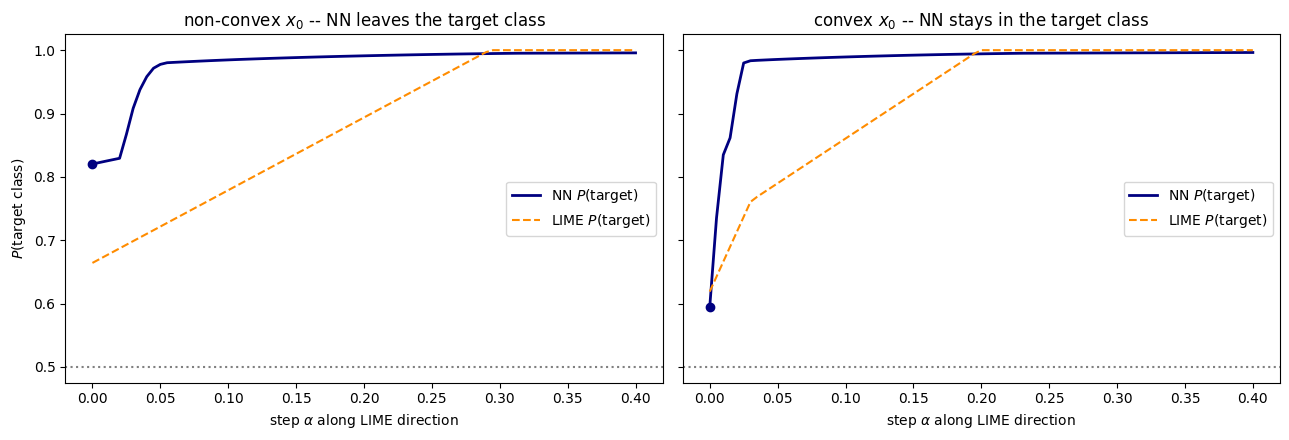

point         P(target) start  P(target) min   verdict
----------------------------------------------------------------
non-convex              0.820          0.820   stays in target (LIME ok)
convex                  0.594          0.594   stays in target (LIME ok)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
panel_data = []
titles = ['non-convex $x_0$ -- NN leaves the target class',
          'convex $x_0$ -- NN stays in the target class']
for ax, idx, title in [(axes[0], nc_idx, titles[0]),
                       (axes[1], conv_idx, titles[1])]:
    if idx is None:
        ax.set_title(title + '  [no candidate]'); continue
    a, f_t, g_t, target, _, _ = push(X_test[idx])
    panel_data.append((title, target, f_t))
    ax.plot(a, f_t, color='navy', lw=2, label='NN $P(\mathrm{target})$')
    ax.axhline(0.5, color='gray', ls=':')
    ax.scatter([0], [f_t[0]], color='navy', zorder=5)
    ax.set_xlabel(r'step $\alpha$ along LIME direction')
    ax.set_title(title); ax.legend(loc='best')
axes[0].set_ylabel('$P(\mathrm{target\ class})$')
plt.tight_layout(); plt.show()

print(f'{"point":12s} {"P(target) start":>16s} {"P(target) min":>14s}   verdict')
print('-' * 64)
for title, target, f_t in panel_data:
    verdict = 'LEAVES target (LIME wrong)' if f_t.min() < 0.5 else 'stays in target (LIME ok)'
    kind = 'non-convex' if 'non-convex' in title else 'convex'
    print(f'{kind:12s} {f_t[0]:>16.3f} {f_t.min():>14.3f}   {verdict}')


### NN vs the convex surrogate at the *same* non-convex point

Counter-intuitive but exactly the point of the method: pick a point where the NN's decision boundary
**bends the wrong way** (a non-convex leaf). Step along the direction *LIME itself* says increases
$P(\text{target})$.

- **Left (NN, being explained):** LIME's own direction drives the NN **across the decision boundary** --
  $P(\text{target})$ drops below $0.5$ and the prediction leaves the target class (shaded band). LIME is
  locally **unfaithful** here.
- **Right (pruned convex surrogate), same point $x_0$:** along *its* LIME direction the surrogate **stays**
  in the target class -- $P(\text{target})$ never drops below $0.5$. LIME is **faithful**.

We search the non-convex pool for the clearest such point (NN drops below $0.5$; the surrogate agrees at
$x_0$ and never leaves the target class). If no such point exists it is reported honestly (no figure).
LIME's RNG is reset per call so the readout and plot agree.

In [ ]:
# NN vs the convex surrogate at the SAME non-convex point (self-contained).
import os
from paper_experiments_utils import (predict_proba, make_lime_explainer,
    push_along_lime, find_nonconvex_leaves, leaf_key_for_point)

if 'nn_proba' not in globals():
    def nn_proba(X_):
        return predict_proba(nn_model, X_, device=device)
if 'explainer' not in globals():
    explainer = make_lime_explainer(X_train, feature_names, n_classes=n_classes)
if 'ALPHA' not in globals():
    ALPHA = np.linspace(0, 0.4, 81)
EPSILON = globals().get('EPSILON', 0.05)

def _softmax(z):
    z = z - z.max(axis=1, keepdims=True); e = np.exp(z); return e / e.sum(axis=1, keepdims=True)

def stc_proba(X_):
    # Smooth probabilities for the pruned surrogate: softmax of its one-vs-rest
    # decision_function (so LIME can fit a meaningful local linear model).
    X_ = np.atleast_2d(np.asarray(X_, dtype=np.float64))
    d = np.asarray(stc_convex.classifier.decision_function(stc_convex.transform(X_)))
    if d.ndim == 1:
        d = np.column_stack([-d, d])
    return _softmax(d)

def push_model(point, proba_fn, target=None):
    # Step along the LIME 'increase P(target)' direction fit to proba_fn at point.
    # Resets LIME's RNG each call so the same point is reproducible across cells.
    point = np.asarray(point, dtype=np.float32)
    if target is None:
        target = int(np.argmax(proba_fn(point)[0]))
    explainer.random_state = np.random.RandomState(0)
    a, p_t, lime_t, w, d = push_along_lime(point, explainer, proba_fn,
        target_label=target, num_features=n_features, alphas=ALPHA)
    xs = np.clip(point + np.outer(ALPHA, d), 0, 1)
    return a, np.asarray(p_t), np.asarray(lime_t), target, np.argmax(proba_fn(xs), 1)

if 'depths' not in globals():
    depths = find_nonconvex_leaves(stc, epsilon=EPSILON)
_td = np.array([depths.get(leaf_key_for_point(stc, x), 0.0) for x in X_test])
_nz = float(np.median(_td[_td > 0])) if (_td > 0).any() else 0.0
_ncpool = np.where(_td >= _nz)[0] if _nz > 0 else np.arange(len(X_test))
print(f'non-convex pool: {len(_ncpool)}')

# Search for the clearest NN-crosses / surrogate-stays point.
_rng = np.random.default_rng(0)
_search = _ncpool if len(_ncpool) <= 120 else _rng.choice(_ncpool, 120, replace=False)
_best = None
for _i in _search:
    _x0 = X_test[int(_i)]
    _aN, _fN, _, _t, _amN = push_model(_x0, nn_proba)
    if (_amN == _t).all():
        continue                                    # NN argmax never leaves target -> not a demo
    _aS, _fS, _, _, _amS = push_model(_x0, stc_proba, target=_t)
    if not (_amS == _t).all():
        continue                                    # surrogate leaves target (or disagrees at x0) -> no contrast
    _score = (_fN[0] - _fN.min()) + _fS.min()       # deep NN drop + surrogate keeps P(target) high
    if _best is None or _score > _best[0]:
        _best = (_score, int(_i), int(_t))

demo2 = _best[1] if _best else None
if demo2 is None:
    print('No NN-crosses / surrogate-stays point found in the searched non-convex pool.')
else:
    print(f'NN-vs-surrogate demo point: test idx {demo2}  (target class {_best[2]})')
    x0 = X_test[demo2].astype(np.float32)
    target = int(np.argmax(nn_proba(x0[None])[0]))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
    specs = [('NN (being explained)',      nn_proba,  axes[0]),
             ('Pruned convex surrogate',   stc_proba, axes[1])]
    summary = []
    for name, fn, ax in specs:
        a, f_t, g_t, tgt, am = push_model(x0, fn, target=target)
        crossed = bool((am != target).any())        # argmax leaves target (correct for multiclass)
        ax.plot(a, f_t, color='navy', lw=2, label=r'$P(\mathrm{target})$')
        off = np.asarray(am) != target
        if off.any():
            ax.fill_between(a, 0, 1, where=off, color='crimson', alpha=0.12,
                            transform=ax.get_xaxis_transform(), label='left target class')
        ax.axhline(0.5, color='gray', ls=':')
        ax.scatter([0], [f_t[0]], color='navy', zorder=5)
        ax.set_xlabel(r'step $\alpha$ along LIME direction'); ax.set_ylim(-0.02, 1.02)
        ax.set_title(f'{name}\n' + ('LIME points the wrong way -- crosses the boundary'
                                    if crossed else 'stays in the target class -- LIME faithful'))
        ax.legend(loc='best', fontsize=9)
        summary.append((name, float(f_t[0]), float(f_t.min()), crossed))
    axes[0].set_ylabel(r'$P(\mathrm{target\ class})$' + f'  (target = {target})')
    plt.suptitle(f'LIME at the SAME non-convex point $x_0$  (test idx {demo2})')
    plt.tight_layout(); plt.show()
    hdr = f'{"model":26s} {"start":>7s} {"min":>7s}   verdict'
    print(hdr); print('-' * len(hdr))
    for name, s, mn, cr in summary:
        print(f'{name:26s} {s:>7.3f} {mn:>7.3f}   '
              + ('CROSSES boundary (LIME unfaithful)' if cr else 'stays (LIME faithful)'))

non-convex pool: 499


No NN-crosses / surrogate-stays point found in the searched non-convex pool.
